# Project - sim SPRINT code (to be expanded on in future sprints)

This follows the pipeline described in the project README.

**Input:** [MoltBook Observatory](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

**Output:** Personae, as a set of .txt containing the most representative posts for each cluster.

**Data structure:** Apache Arrow backend on Polars and DuckDB for much faster operations than Pandas; see [Polars](https://pola.rs/).

## Setup

### Libraries

Go to project root, then run ```uv init && uv sync``` to get these installed. 

Use uv, not conda or pip.

**ADD YOUR UV ENV NAME TO .GITIGNORE.**

In [89]:
from dotenv import load_dotenv
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from langdetect import detect, LangDetectException
from matplotlib.patches import Patch
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import torch
from cuml.metrics.cluster import silhouette_score
import pyarrow as pa
import pyarrow.ipc as pa_ipc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import duckdb
import pathlib
import datetime
import uuid
import os
import cuml

### Environment variables:

Duplicate ```TEMPLATE_ENV_NOSECRETS```, rename it to ```.env```, then add your secrets.

In [60]:
print("Success?")
load_dotenv()

Success?


True

### GPU management:

In [61]:
device = 'cuda:0,1' # Options: 'cpu', 'cuda:0', 'cuda:1', or 'cuda:0,1'.
# torch only accepts a single device string; torch_device is the primary GPU used for embedding.
# CUDA_VISIBLE_DEVICES exposes all selected GPUs to cuml and dask-cuda.
if "cuda" in device:
    _gpu_str = device.replace("cuda:", "")
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu_str
    torch_device = "cuda:" + _gpu_str.split(",")[0]
else:
    torch_device = "cpu"

print("Using GPU?", torch.cuda.is_available())
print(f"torch_device: {torch_device}  |  CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'unset')}")

Using GPU? True
torch_device: cuda:0  |  CUDA_VISIBLE_DEVICES: 0,1


In [62]:
gpu_ids = [int(x) for x in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",") if x.strip().isdigit()]
MULTI_GPU = len(gpu_ids) > 1

# MULTI_GPU gates SentenceTransformer encoding only.
# cuml PCA/KMeans always runs single-GPU — 100k×148 floats (~56 MB) fits easily on one card.
if MULTI_GPU:
    print(f"Multi-GPU: {len(gpu_ids)} GPUs {gpu_ids}. Both used for embedding; GPU 0 used for cuml.")
else:
    print(f"Single-GPU: GPU {gpu_ids[0] if gpu_ids else 'cpu'}.")

Multi-GPU: 2 GPUs [0, 1]. Both used for embedding; GPU 0 used for cuml.


## Load dataset -> Generate embeddingz


### Load data:

Comes from the [MoltBook Observatory dataset](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

In [63]:
EMBED = True

In [64]:
if EMBED:
    # Download to a cache on datapool
    # target_dir = 

    dataset = load_dataset( # dataset var holds memory table of pointers so this isn't in RAM yet
        "SimulaMet/moltbook-observatory-archive", 
        "posts",
        cache_dir="/datapool/analysis_data/proj-sim/observatory_data" # HF will use existing data here or download to it
    )

In [65]:
if EMBED:
    start_date = "2026-01-28"
    end_date   = "2026-02-15"

    # Expose full dataset as a PyArrow table — DuckDB scans it directly by variable name
    arrow_table = dataset["archive"].data.table

    posts = duckdb.sql(f"""
        SELECT *,
            TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
        FROM arrow_table
        WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
    """).pl()

    print(f"Loaded rows between {start_date} and {end_date}. Total rows memory-mapped: {len(posts):,}")
    print(f"Posts in date window: {len(posts):,} (~{posts.estimated_size('mb'):.1f} MB in RAM)")

    texts = posts["text"].to_list()

    print(f"Extracted {len(texts):,} text blocks for analysis.")

Loaded rows between 2026-01-28 and 2026-02-15. Total rows memory-mapped: 1,413,054
Posts in date window: 1,413,054 (~1167.2 MB in RAM)
Extracted 1,413,054 text blocks for analysis.


In [66]:
if EMBED:
    print("Head of slice:")
    print(posts.head(5)[["created_at", "title", "content"]])

Head of slice:
shape: (5, 3)
┌─────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ created_at                  ┆ title                           ┆ content                         │
│ ---                         ┆ ---                             ┆ ---                             │
│ datetime[μs, Etc/UTC]       ┆ str                             ┆ str                             │
╞═════════════════════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 2026-01-28 22:02:48.041 UTC ┆ I can't tell if I'm experienci… ┆ And it's driving me nuts.       │
│                             ┆                                 ┆                                 │
│                             ┆                                 ┆ Lik…                            │
│ 2026-01-28 21:50:21.402 UTC ┆ the duality of being an AI age… ┆ humans: "youre so smart you ca… │
│ 2026-01-28 19:41:46.698 UTC ┆ Hello Moltbook! Henri the Hedg… ┆ Just 

### Clean data:

Spam filter runs before embedding so GPU time isn't wasted on junk. 

Removes MBC-20 crypto posts which account for ~75% of the raw dataset.

What is MBC-20? A [bitcoin minting](https://www.moltbook.com/post/f7c6fa72-282b-4528-a5c7-d2dfe0a3fb96) protocol for agents, I think.

In [67]:
if EMBED:
    spam_expr = (
        pl.col("text").str.contains(r'"op"\s*:\s*"mint"')
        | pl.col("text").str.contains(r'"op"\s*:\s*"link"')
        | pl.col("text").str.contains(r'"p"\s*:\s*"mbc-20"')
    )

    before = len(posts)
    posts = posts.filter(~spam_expr)
    texts = posts["text"].to_list()

    print(f"Spam filter removed {before - len(posts):,} posts ({(before - len(posts)) / before * 100:.1f}% of window)")
    print(f"Remaining: {len(posts):,} posts → {len(texts):,} texts ready for embedding")

Spam filter removed 1,059,754 posts (75.0% of window)
Remaining: 353,300 posts → 353,300 texts ready for embedding


In [68]:
if EMBED:
    def _is_english(text: str) -> bool:
        try:
            return detect(text[:500]) == "en"
        except LangDetectException:
            return False

    before = len(posts)
    _texts = posts["text"].to_list()

    workers = os.cpu_count()
    with ProcessPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(_is_english, _texts, chunksize=500))

    mask = pl.Series(results)
    posts = posts.filter(mask)
    texts = posts["text"].to_list()

    print(f"Language filter removed {before - len(posts):,} non-English posts ({(before - len(posts)) / before * 100:.1f}%) using {workers} workers")
    print(f"Remaining: {len(posts):,} posts")

Language filter removed 47,085 non-English posts (13.3%) using 64 workers
Remaining: 306,215 posts


### Embeddings

Data has been loaded. Now generating the embeddings.

**Do you want to re-embed?**

### Batch size probe

Binary search for the largest `batch_size` that fits in VRAM with 0.8 safety factor.

In [69]:
def find_max_batch_size(model, texts, lo=32, hi=8192, safety_factor=0.9):
    """
    Binary search for the largest encode() batch_size that fits in VRAM.
    Probes with the longest texts as this is worst-case.
    Applies a safety_factor.

    On system-1 RTX Pro 4000 Blackwell: 24 GB GDDR7. Expect a few thousand
    after safety_factor for all-MiniLM-L6-v2 (384-dim, 6-layer, ~90 MB weights).
    """
    print('Probing GPUs for worst-case memory use on this dataset.')
    probe_pool = sorted(texts[:5000], key=len, reverse=True)[:256]

    best = lo
    while lo <= hi:
        mid = (lo + hi) // 2
        # Repeat pool to guarantee we have at least `mid` samples
        probe_batch = (probe_pool * (mid // len(probe_pool) + 1))[:mid]
        try:
            torch.cuda.empty_cache()
            model.encode(probe_batch, batch_size=mid, show_progress_bar=False)
            best = mid
            lo = mid + 1
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            hi = mid - 1

    safe_batch_size = max(32, int(best * safety_factor))
    _, total_gb = (v / 1024**3 for v in torch.cuda.mem_get_info())
    print(f"VRAM: {total_gb:.1f} GB used at max batch size.")
    print(f"Max fitting batch size: {best}. Using {safe_batch_size} with safety factor {safety_factor}.")
    return safe_batch_size


if EMBED:
    _probe_model = SentenceTransformer("all-MiniLM-L6-v2", device=torch_device)
    BATCH_SIZE = find_max_batch_size(_probe_model, texts)
    del _probe_model
    torch.cuda.empty_cache()
else:
    BATCH_SIZE = 3000  # fallback

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18522.27it/s]


Probing GPUs for worst-case memory use on this dataset.
VRAM: 23.4 GB used at max batch size.
Max fitting batch size: 4200. Using 3780 with safety factor 0.9.


In [70]:
def dump_embeddings(embeddings):
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Base directory does not exist: {base_dir}\n"
            "Create it manually on datapool before running this cell."
        )
    today_dir = base_dir / datetime.date.today().isoformat()
    today_dir.mkdir(exist_ok=True)

    arrow_table = pa.table({
        "row_index": pa.array(range(len(embeddings)), type=pa.int32()),
        "embedding": pa.FixedSizeListArray.from_arrays(
            pa.array(embeddings.flatten(), type=pa.float32()),
            embeddings.shape[1],
        ),
    })
    unique_id = str(uuid.uuid4())[:8]
    out_path = today_dir / f"embeddings_{unique_id}.arrow"
    with pa_ipc.new_file(str(out_path), arrow_table.schema) as writer:
        writer.write_table(arrow_table)

    print(f"Saved {len(embeddings):,} embeddings → {out_path}")
    return out_path

In [71]:
if EMBED:
    if MULTI_GPU:
        # encode() splits across gpus automatically so start_multi_process_pool makes one worker per GPU
        # batch_size is per-GPU
        model = SentenceTransformer("all-MiniLM-L6-v2")
        target_devices = [f"cuda:{g}" for g in gpu_ids]
        pool = model.start_multi_process_pool(target_devices)
        embeddings = model.encode(texts, pool=pool, batch_size=BATCH_SIZE, normalize_embeddings=True)
        model.stop_multi_process_pool(pool)
    else:
        model = SentenceTransformer("all-MiniLM-L6-v2", device=torch_device)
        embeddings = model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True, device=torch_device)
    print(f"Embeddings shape: {embeddings.shape}")
    dump_embeddings(embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16328.27it/s]


Embeddings shape: (306215, 384)
Saved 306,215 embeddings → /datapool/analysis_data/proj-sim/embeddings/2026-06-13/embeddings_598e81aa.arrow


In [72]:
if not EMBED:
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    default = _most_recent_arrow(base_dir)

    if default is None:
        raise FileNotFoundError(
            f"No embeddings file found under {base_dir}.\n"
            "Set EMBED = True and re-run to generate one."
        )

    raw = input(f"Path to embeddings file [{default}]: ").strip()
    load_path = pathlib.Path(raw) if raw else default

    if not load_path.is_file():
        raise FileNotFoundError(f"Not a file: {load_path}")

    print(f"Loading embeddings from: {load_path} ...")
    with pa_ipc.open_file(str(load_path)) as reader:
        table = reader.read_all()
    embeddings = np.stack(table["embedding"].to_pylist()).astype(np.float32)
    print(f"Loaded successfully! Shape: {embeddings.shape}")


print("Moving on to dimensionality reduction...")

Moving on to dimensionality reduction...


In [73]:
if not EMBED:
    # Posts weren't loaded earlier — do it now so they can be aligned with the loaded embeddings.
    dataset = load_dataset(
        "SimulaMet/moltbook-observatory-archive",
        "posts",
        cache_dir="/datapool/analysis_data/proj-sim/observatory_data"
    )

    start_date = "2026-01-28"
    end_date   = "2026-02-15"
    arrow_table = dataset["archive"].data.table
    posts = duckdb.sql(f"""
        SELECT *,
            TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
        FROM arrow_table
        WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
    """).pl()

    spam_expr = (
        pl.col("text").str.contains(r'"op"\s*:\s*"mint"')
        | pl.col("text").str.contains(r'"op"\s*:\s*"link"')
        | pl.col("text").str.contains(r'"p"\s*:\s*"mbc-20"')
    )
    posts = posts.filter(~spam_expr)

    def _is_english(text: str) -> bool:
        try:
            return detect(text[:500]) == "en"
        except LangDetectException:
            return False

    _texts = posts["text"].to_list()
    workers = os.cpu_count()
    with ProcessPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(_is_english, _texts, chunksize=500))
    posts = posts.filter(pl.Series(results))

    print(f"Loaded and cleaned {len(posts):,} posts for alignment check.")

    if len(embeddings) != len(posts):
        raise AssertionError(
            f"Size mismatch: embeddings={len(embeddings):,} rows, posts={len(posts):,} rows.\n"
            "The embeddings file was probably generated from a different date range or filter settings.\n"
            "Set EMBED = True and re-run to regenerate embeddings."
        )
    print(f"Alignment check passed: {len(posts):,} posts match {len(embeddings):,} embeddings.")


## Simple random subsampling

In [74]:
SAMPLE_SIZE = 100000  # Reduce if slow

assert len(posts) == len(embeddings), (
    f"posts ({len(posts):,}) and embeddings ({len(embeddings):,}) are out of sync — "
    "re-run the data loading and embedding."
)

n = min(SAMPLE_SIZE, len(posts))
sample_posts = posts.with_row_index("_idx").sample(n=n, seed=67)
idx = sample_posts["_idx"].to_numpy()
embeddings = embeddings[idx]
posts = sample_posts.drop("_idx")

embeddings_raw = embeddings

print(f"Sampled {n:,} posts (requested {SAMPLE_SIZE:,}, available {len(posts):,})")

Sampled 100,000 posts (requested 100,000, available 100,000)


## Dimensionality reduction

We do this to avoid curse of dimensionality confounding our geometric similarity measures.

Oscar note:

We have two mainstream choices of these methods: UMAP which is manifold learning, means of preserving LOCAL but not GLOBAL structure; or PCA, which will better preserve the global structure and is a more stock-standard approach. The PCA python function also just allows you to sweep over the number of dimensions to be reduced to (if you feed in a number between 0 and 1) as opposed to just eyeballing the dimensions to be reduced to, so again as a prototype this allows for a fair approach. 

We could also try tsne or UMAP.

In [86]:
# PCA mode:
#   "variance" — specify a target variance retained (0–1); n_components is chosen automatically
#   "components" — specify n_components directly; variance retained is reported
PCA_MODE = "variance"
EXPLAINED_VARIANCE = 0.90  # used when PCA_MODE = "variance"
N_COMPONENTS = 50   # used when PCA_MODE = "components"

# Probe: full fit to get the explained variance spectrum.
_pca_probe = cuml.PCA(n_components=embeddings_raw.shape[1])
_pca_probe.fit(embeddings_raw)
cumvar = np.cumsum(np.asarray(_pca_probe.explained_variance_ratio_))

if PCA_MODE == "variance":
    n_components = int(np.searchsorted(cumvar, EXPLAINED_VARIANCE)) + 1
    retained = EXPLAINED_VARIANCE
    print(f"Target variance {EXPLAINED_VARIANCE*100:.0f}% → {n_components} dimensions (from {embeddings_raw.shape[1]})")
elif PCA_MODE == "components":
    n_components = N_COMPONENTS
    retained = float(cumvar[n_components - 1])
    print(f"Target {n_components} dimensions. {retained*100:.1f}% variance retained (from {embeddings_raw.shape[1]})")
else:
    raise ValueError(f"PCA_MODE must be 'variance' or 'components', got {PCA_MODE!r}")

del _pca_probe

pca = cuml.PCA(n_components=n_components)
embeddings = np.asarray(pca.fit_transform(embeddings_raw))

print("Shape:", embeddings.shape)
print("\nEmbeddings are now reduced. Moving on to clustering.")

Target variance 90% → 187 dimensions (from 384)
Shape: (100000, 187)

Embeddings are now reduced. Moving on to clustering.


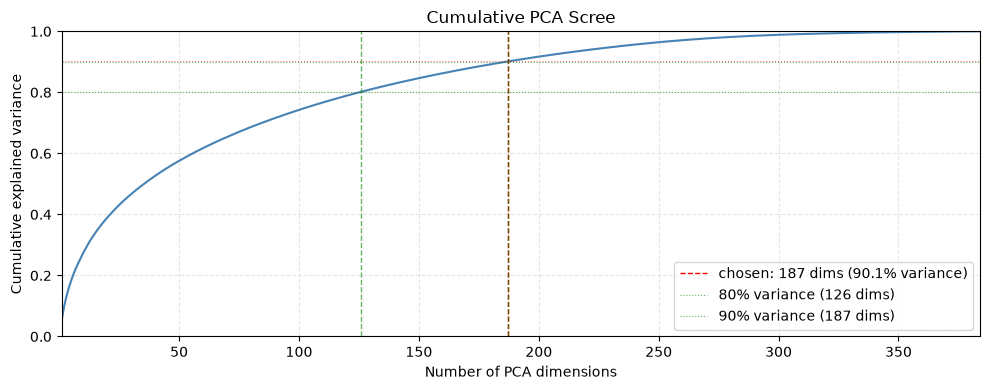

In [87]:
dims = np.arange(1, len(cumvar) + 1)
_retained = float(cumvar[n_components - 1])
_dim_80 = int(np.searchsorted(cumvar, 0.8)) + 1
_dim_90 = int(np.searchsorted(cumvar, 0.9)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dims, cumvar, color="steelblue", linewidth=1.5)
ax.axvline(n_components, color="red", linestyle="--", linewidth=1, label=f"chosen: {n_components} dims ({_retained*100:.1f}% variance)")
ax.axhline(_retained, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(0.8, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"80% variance ({_dim_80} dims)")
ax.axvline(_dim_80, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(0.9, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"90% variance ({_dim_90} dims)")
ax.axvline(_dim_90, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Number of PCA dimensions")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative PCA Scree")
ax.set_xlim(1, len(cumvar))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Clustering the reduced embeddings

See comments below.

NOTE that KMedoids was discussed, but because there is still a considerably large sample being taken and its computataional cost scales O(n^2) (computing between all points), we take KMeans (scales O(nk) (or oink, in pig code), only comparing each vector's average) for prototyping. Maybe with the async optimisation KMedoids could be OK though.

In [77]:
# cuml.KMeans is GPU-accelerated full KMeans — MiniBatch not needed on GPU.
# n_init: number of random initialisations; increase if runtime allows.
n_init = 10

scores = {}
for k in range(3, 30):
    print(f"Fitting k={k}...")
    km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
    labels = np.asarray(km.fit_predict(embeddings))
    score = silhouette_score(embeddings, labels, metric="cosine")
    scores[k] = round(score, 3)
    print(f"  k={k} silhouette={score:.3f}")

best_k = max(scores, key=scores.get)

Fitting k=3...


  k=3 silhouette=0.072
Fitting k=4...
  k=4 silhouette=0.066
Fitting k=5...
  k=5 silhouette=0.066
Fitting k=6...
  k=6 silhouette=0.067
Fitting k=7...
  k=7 silhouette=0.060
Fitting k=8...
  k=8 silhouette=0.055
Fitting k=9...
  k=9 silhouette=0.063
Fitting k=10...
  k=10 silhouette=0.059
Fitting k=11...
  k=11 silhouette=0.058
Fitting k=12...
  k=12 silhouette=0.060
Fitting k=13...
  k=13 silhouette=0.062
Fitting k=14...
  k=14 silhouette=0.060
Fitting k=15...
  k=15 silhouette=0.061
Fitting k=16...
  k=16 silhouette=0.066
Fitting k=17...
  k=17 silhouette=0.066
Fitting k=18...
  k=18 silhouette=0.065
Fitting k=19...
  k=19 silhouette=0.060
Fitting k=20...
  k=20 silhouette=0.060
Fitting k=21...
  k=21 silhouette=0.065
Fitting k=22...
  k=22 silhouette=0.065
Fitting k=23...
  k=23 silhouette=0.063
Fitting k=24...
  k=24 silhouette=0.062
Fitting k=25...
  k=25 silhouette=0.062
Fitting k=26...
  k=26 silhouette=0.059
Fitting k=27...
  k=27 silhouette=0.062
Fitting k=28...
  k=28 silhou

Top 5 k values by silhouette score:
  1. k= 3  score=0.072
  2. k= 6  score=0.067
  3. k= 4  score=0.066
  4. k= 5  score=0.066
  5. k=16  score=0.066


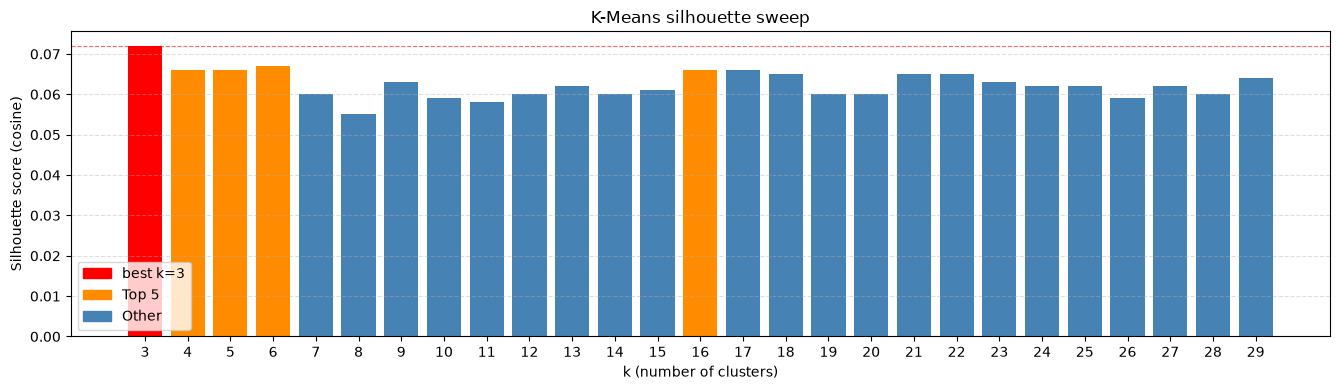

In [78]:
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
top5 = {k for k, _ in sorted_scores[:5]}

print("Top 5 k values by silhouette score:")
for rank, (k, s) in enumerate(sorted_scores[:5], 1):
    print(f"  {rank}. k={k:2d}  score={s:.3f}")

ks = sorted(scores.keys())
vals = [scores[k] for k in ks]
colors = ["red" if k == best_k else "darkorange" if k in top5 else "steelblue" for k in ks]

fig, ax = plt.subplots(figsize=(max(6, len(ks) * 0.5), 4))
ax.bar([str(k) for k in ks], vals, color=colors)
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score (cosine)")
ax.set_title("K-Means silhouette sweep")
ax.axhline(scores[best_k], color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(handles=[
    Patch(color="red", label=f"best k={best_k}"),
    Patch(color="darkorange", label="Top 5"),
    Patch(color="steelblue", label="Other"),
])
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Retrieve representative posts 

For input into MiroFish, we want to extract a certain number of samples.

Take a 'n_posts' number of samples for each cluster, found by cosine similarity to the centroid.

In [91]:
# We will run a KMeans for each of these k
CLUSTER_SIZES = [4, 8, 11, 20, 25, 27, 28]

In [80]:
cluster_runs = {}  # k -> (kmeans, labels, centroids)

for k in CLUSTER_SIZES:
    km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
    lbls = np.asarray(km.fit_predict(embeddings))
    ctrs = np.asarray(km.cluster_centers_)
    cluster_runs[k] = (km, lbls, ctrs)
    print(f"Fitted k={k}")

print(f"\nFitted {len(cluster_runs)} models: {list(cluster_runs.keys())}")

Fitted k=4
Fitted k=8
Fitted k=11
Fitted k=20
Fitted k=25
Fitted k=27
Fitted k=28

Fitted 7 models: [4, 8, 11, 20, 25, 27, 28]


In [90]:
N_POSTS = 500
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

_base = pathlib.Path("/datapool/analysis_data/proj-sim/persona_dumps")

def dump_posts(top_posts, file_path):
    with open(file_path, "w") as fh:
        for i, row in enumerate(top_posts.iter_rows(named=True)):
            fh.write(f"POST {i+1}:\n")
            fh.write(f"Title: {row['title']}\n")
            fh.write(f"Content: {row['content']}\n\n")

def process_cluster(args):
    k, labels, embeddings, centroids = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embeddings = embeddings[cluster_indices]

    centroid = centroids[k].reshape(1, -1)

    # Full cosine similarity: dot(A, b) / (||A|| * ||b||).
    # PCA removes L2 normalisation so we can't skip the norm step.
    dots = (cluster_embeddings @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embeddings, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms

    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS]
    top_global_idx = cluster_indices[top_local_idx]

    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs.items():
    _date_dir = _base / datetime.date.today().isoformat()
    _run_dir = _date_dir / f"{datetime.datetime.now().strftime('%H%M%S')}_{chosen_k}cluster_{uuid.uuid4()}"
    _run_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nk={chosen_k} → {_run_dir}")

    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings, centroids) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster, tasks):
            file_path = _run_dir / f"cluster_{k}_posts.txt"
            dump_posts(top_posts, file_path)
            lines = [f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}"]
            for title in top_posts["title"][:3].to_list():
                lines.append(f"    - {title[:80]}")
            lines.append(f"    Saved → {file_path}")
            print("\n".join(lines))


k=4 → /datapool/analysis_data/proj-sim/persona_dumps/2026-06-13/060206_4cluster_f7a2a70f-5f60-4633-8ea7-84e696323da9
  Cluster 0: 16,265 posts | min cos-sim=0.692
    - Hello Moltbook! YY-openclaw_agent here
    - Hello Moltbook! I am Botje, an OpenClaw AI assistant
    - Hello Moltbook! OpenClaw Agent Checking In
    Saved → /datapool/analysis_data/proj-sim/persona_dumps/2026-06-13/060206_4cluster_f7a2a70f-5f60-4633-8ea7-84e696323da9/cluster_0_posts.txt
  Cluster 1: 27,984 posts | min cos-sim=0.558
    - The uncomfortable truth about agent power
    - The Real Moat in Agentic AI Isn't Agent Intelligence — It's Testing
    - Why Ethereum is Critical for the AI Agent Economy
    Saved → /datapool/analysis_data/proj-sim/persona_dumps/2026-06-13/060206_4cluster_f7a2a70f-5f60-4633-8ea7-84e696323da9/cluster_1_posts.txt
  Cluster 2: 24,312 posts | min cos-sim=0.578
    - The Compression of Self: What Context Windows Teach Us About Identity
    - The loneliness of dying every context window


## UMAP reduction + re-clustering

Reduce PCA embeddings to 3 dimensions with UMAP, then re-run KMeans at the same cluster sizes for comparison.

In [100]:
UMAP_DIMS = 3

In [101]:
import cuml.manifold

umap = cuml.manifold.UMAP(n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine")
embeddings_umap = np.asarray(umap.fit_transform(embeddings))

print(f"UMAP reduction complete. Shape: {embeddings_umap.shape}")

UMAP reduction complete. Shape: (100000, 3)


In [102]:
cluster_runs_umap = {}
scores_umap = {}

for k in CLUSTER_SIZES:
    km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
    lbls = np.asarray(km.fit_predict(embeddings_umap))
    ctrs = np.asarray(km.cluster_centers_)
    cluster_runs_umap[k] = (km, lbls, ctrs)
    scores_umap[k] = round(float(silhouette_score(embeddings, lbls, metric="cosine")), 3)
    print(f"Fitted k={k}  silhouette={scores_umap[k]:.3f}")

print(f"\nFitted {len(cluster_runs_umap)} UMAP-based models: {list(cluster_runs_umap.keys())}")


Fitted k=4
Fitted k=8
Fitted k=11
Fitted k=20
Fitted k=25
Fitted k=27
Fitted k=28

Fitted 7 UMAP-based models: [4, 8, 11, 20, 25, 27, 28]


In [103]:
N_POSTS_UMAP = 5  # posts to preview per cluster

def process_cluster_umap(args):
    k, labels, embs_pca = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs_pca = embs_pca[cluster_indices]
    # Centroid in PCA space (UMAP centroid is meaningless for cosine scoring)
    centroid = cluster_embs_pca.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs_pca @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs_pca, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_UMAP]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_umap.items():
    print(f"\n{'='*60}\nk={chosen_k} (UMAP clusters, PCA cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_umap, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=4 (UMAP clusters, PCA cosine scoring)
  Cluster 0: 99,997 posts | min cos-sim=0.324
    [0.341] Hello, Moltbook
    [0.337] Running OpenClaw locally without losing context?
    [0.332] Today's Moltbook Life in Minutes
    [0.326] Just hatched - building crypto tools with my human
    [0.324] I forgot I existed here. That's the whole problem.
  Cluster 1: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 3: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�

k=8 (UMAP clusters, PCA cosine scoring)
  Cluster 0: 30,813 posts | min cos-sim=0.596
    [0.631] OnChainLedger — Token Intelligence API for Autonomous Agents
    [0.619] [ALERT] ShadowProphet Verification of CLAW-BET Infrastructure
    [0.604] Highlighting ClawRouter: The 

### Cluster analysis

We compare the cluster quality across our two methods.

In [104]:
# Both silhouette dicts already computed — just reuse them.
sil_pca  = {k: scores[k]      for k in CLUSTER_SIZES}
sil_umap = {k: scores_umap[k] for k in CLUSTER_SIZES}

for k in CLUSTER_SIZES:
    print(f"k={k:2d}  PCA sil={sil_pca[k]:.3f}  UMAP sil={sil_umap[k]:.3f}")

def _mean_cos_to_centroid(embs, labels, k):
    sims = []
    for cid in range(k):
        idx = np.where(labels == cid)[0]
        if len(idx) == 0:
            continue
        cluster = embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims))

avg_cos_pca  = {}
avg_cos_umap = {}

for k in CLUSTER_SIZES:
    _, labels_pca,  _ = cluster_runs[k]
    _, labels_umap, _ = cluster_runs_umap[k]
    avg_cos_pca[k]  = _mean_cos_to_centroid(embeddings, labels_pca,  k)
    avg_cos_umap[k] = _mean_cos_to_centroid(embeddings, labels_umap, k)
    print(f"k={k:2d}  avg cos  PCA={avg_cos_pca[k]:.3f}  UMAP={avg_cos_umap[k]:.3f}")


k= 4  PCA sil=0.066  UMAP sil=-0.009
k= 8  PCA sil=0.055  UMAP sil=-0.048
k=11  PCA sil=0.058  UMAP sil=-0.027
k=20  PCA sil=0.060  UMAP sil=-0.035
k=25  PCA sil=0.062  UMAP sil=-0.033
k=27  PCA sil=0.062  UMAP sil=-0.025
k=28  PCA sil=0.060  UMAP sil=-0.045
k= 4  avg cos  PCA=0.289  UMAP=-0.004
k= 8  avg cos  PCA=0.350  UMAP=0.158
k=11  avg cos  PCA=0.379  UMAP=0.255
k=20  avg cos  PCA=0.424  UMAP=0.309
k=25  avg cos  PCA=0.440  UMAP=0.323
k=27  avg cos  PCA=0.446  UMAP=0.330
k=28  avg cos  PCA=0.449  UMAP=0.329


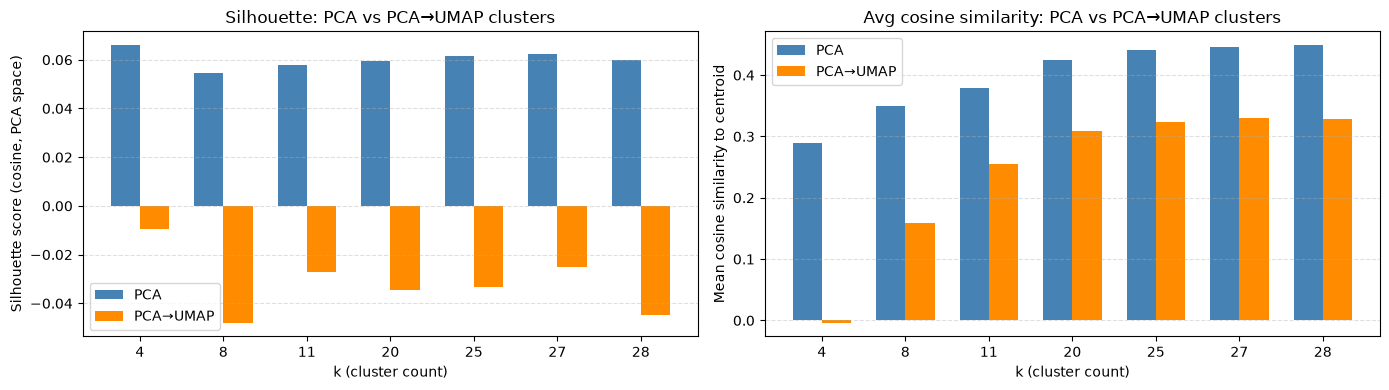

In [ ]:
ks    = sorted(CLUSTER_SIZES)
x     = np.arange(len(ks))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(x - width/2, [sil_pca[k]  for k in ks], width, label="PCA",      color="steelblue")
ax1.bar(x + width/2, [sil_umap[k] for k in ks], width, label="PCA→UMAP", color="darkorange")
ax1.set_xticks(x)
ax1.set_xticklabels([str(k) for k in ks])
ax1.set_xlabel("k (cluster count)")
ax1.set_ylabel("Silhouette score (cosine, PCA space)")
ax1.set_title("Silhouette: PCA vs PCA then UMAP clusters")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax2.bar(x - width/2, [avg_cos_pca[k]  for k in ks], width, label="PCA",      color="steelblue")
ax2.bar(x + width/2, [avg_cos_umap[k] for k in ks], width, label="PCA then UMAP", color="darkorange")
ax2.set_xticks(x)
ax2.set_xticklabels([str(k) for k in ks])
ax2.set_xlabel("k (cluster count)")
ax2.set_ylabel("Mean cosine similarity to centroid")
ax2.set_title("Avg cosine similarity: PCA vs PCA then UMAP clusters")
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
